# African Youth Career Income Model

**Mission:** Help young Africans enter technology and other skilled careers through practical teaching, bootcamps, mentorship, internships, and employer partnerships.

**Use case:** Estimate monthly employee income for a young person in the Rwanda Labour Force Survey. This is a planning estimate, not a promised salary.

## Dataset and target

The source is the official [Rwanda Labour Force Survey 2024](https://microdata.statistics.gov.rw/index.php/catalog/114), produced by the National Institute of Statistics of Rwanda.

To avoid leakage, one observation was kept when the same respondent appeared in more than one survey round. 

In [13]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from API.config import MODEL_FEATURES, NUMERIC_FEATURES, TARGET
from API.training import (
    RANDOM_STATE,
    build_sgd_loss_curve,
    calculate_metrics,
    make_pipeline,
    model_definitions,
    split_data,
    tune_sgd,
)

DATA_PATH = PROJECT_DIR / "data" / "rwanda_youth_employee_income.csv"
MODEL_PATH = PROJECT_DIR / "models" / "best_model.joblib"

data = pd.read_csv(DATA_PATH)
print("Rows and columns:", data.shape)
data.head()

Rows and columns: (6532, 10)


,age,education_level,career_field,main_sector,employer_type,contract_type,weekly_hours,residence,province,monthly_income_rwf
0,19,Lower secondary education,Sales and services,Services,Private business or VUP,Oral agreement,48.0,Urban,Kigali city,26000.0
1,19,Lower secondary education,Science and engineering,Industry,Private business or VUP,Oral agreement,54.0,Urban,Kigali city,40000.0
2,21,Lower secondary education,Elementary and other work,Industry,Private business or VUP,Oral agreement,48.0,Urban,Kigali city,156000.0
3,24,Primary education,Elementary and other work,Agriculture,Private business or VUP,Oral agreement,6.0,Urban,Kigali city,39000.0
4,17,Primary education,Elementary and other work,Services,Household,Oral agreement,70.0,Urban,Kigali city,15000.0


## Feature engineering

| Survey field | Model field | Reason |
|---|---|---|
| `A04` | age | Restricts the model to the survey's youth range |
| `B02A` | education level | Represents the highest level attended |
| `isco2digit` | career field | Groups detailed occupations into readable pathways, including ICT |
| `main_sect` | main sector | Separates agriculture, industry, and services |
| `D04` | employer type | Captures public, private, household, NGO, and other employers |
| `D06` | contract type | Distinguishes oral and written agreements |
| `usual_h` | weekly hours | Numeric measure of work intensity |
| `Code_UR`, `province` | residence, province | Captures broad labour-market location |
| `cash` | monthly income | Continuous regression target in RWF |

Names, household identifiers, gender, detailed district, survey weights, and unused survey questions are dropped.

In [14]:
def group_occupation(occupation):
    value = occupation.lower()
    if "information and communications" in value:
        return "ICT"
    if "science and engineering" in value or "electrical and electronic" in value:
        return "Science and engineering"
    if any(word in value for word in ["teaching", "health", "legal, social", "personal care"]):
        return "Education, health and social services"
    if any(word in value for word in ["manager", "chief executives", "business and administration", "clerks", "customer services", "numerical and material"]):
        return "Business, management and office work"
    if any(word in value for word in ["sales", "personal service", "food preparation", "protective services", "street and related"]):
        return "Sales and services"
    if any(word in value for word in ["building and related", "metal, machinery", "craft", "drivers", "plant and machine", "assemblers", "handicraft"]):
        return "Skilled trades and operators"
    if any(word in value for word in ["agricultural", "forestry", "fishery"]):
        return "Agriculture"
    return "Elementary and other work"


def prepare_survey_data(raw):
    clean = raw.copy()
    for column in ["A04", "cash", "usual_h"]:
        clean[column] = pd.to_numeric(clean[column], errors="coerce")

    clean = clean[
        clean["A04"].between(16, 30)
        & clean["D05"].eq("Employee")
        & clean["D12"].eq("Amount(Rwf)")
        & clean["cash"].notna()
    ]
    clean = clean.drop_duplicates(["HHID", "pid"], keep="first")
    lower, upper = clean["cash"].quantile([0.01, 0.99])
    clean = clean[clean["cash"].between(lower, upper)].copy()

    clean["career_field"] = clean["isco2digit"].map(group_occupation)
    clean["employer_type"] = clean["D04"].replace({
        "Private/VUP": "Private business or VUP",
        "Public  institution/enterprise": "Public institution",
        "Mixed public and private enterprise": "Public-private enterprise",
        "Local NGO/Religious organisation": "NGO or international organisation",
        "International NGO/International organisation": "NGO or international organisation",
        "Others(Specify)": "Other",
    })
    clean = clean.rename(columns={
        "A04": "age",
        "B02A": "education_level",
        "D06": "contract_type",
        "usual_h": "weekly_hours",
        "main_sect": "main_sector",
        "Code_UR": "residence",
        "cash": "monthly_income_rwf",
    })
    return clean[MODEL_FEATURES + [TARGET]]


print("The function above shows how the downloaded survey export became the prepared data.")

The function above shows how the downloaded survey export became the prepared data.


In [15]:
for column in NUMERIC_FEATURES + [TARGET]:
    data[column] = pd.to_numeric(data[column], errors="coerce")

quality = pd.DataFrame({
    "type": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique_values": data.nunique(),
})
quality

,type,missing,unique_values
age,int64,0,15
education_level,object,0,6
career_field,object,0,8
main_sector,object,0,3
employer_type,object,0,7
contract_type,object,0,2
weekly_hours,float64,0,86
residence,object,0,2
province,object,0,5
monthly_income_rwf,float64,0,219


## Visualization 1: income distribution

Monthly income is right-skewed: most observations are toward the lower end and a smaller group earns much more. RMSE will therefore punish large mistakes strongly.

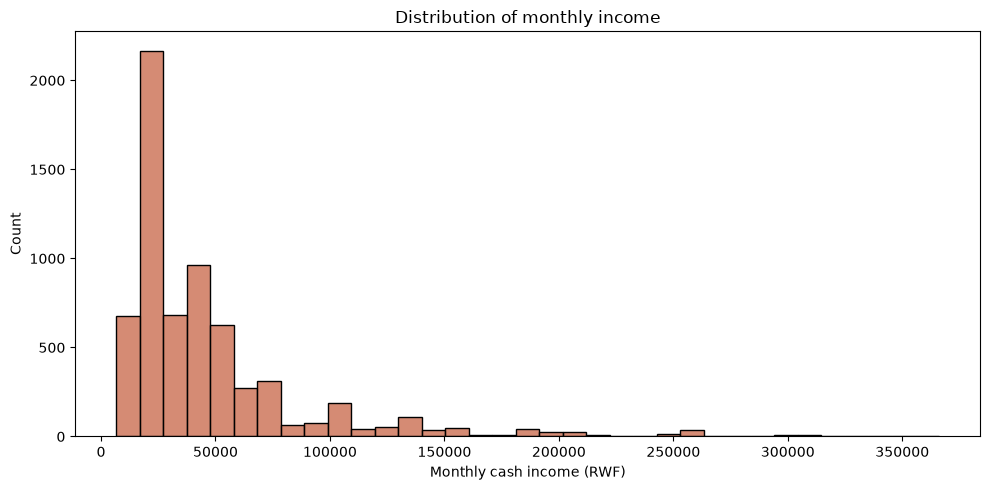

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(data[TARGET], bins=35, color="#c86545")
plt.xlabel("Monthly cash income (RWF)")
plt.title("Distribution of monthly income")
plt.tight_layout()
plt.show()

## Visualization 2: numeric correlation

The heatmap checks the direction and strength of simple numeric relationships. Age and weekly hours alone do not explain income, so categorical education and career information should remain in the model.

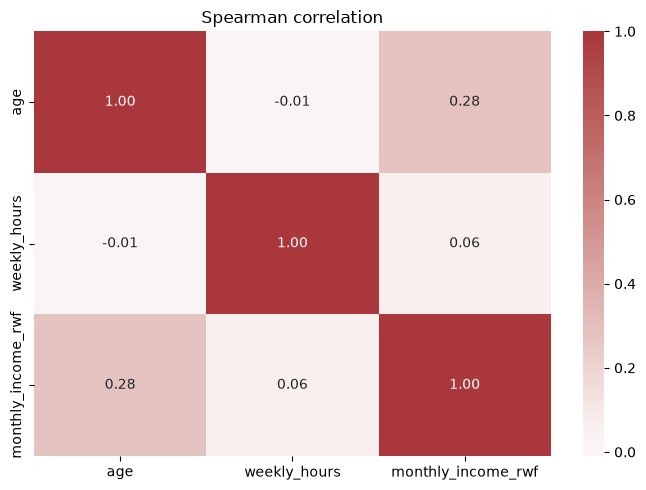

In [17]:
correlation = data[NUMERIC_FEATURES + [TARGET]].corr(method="spearman")
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Spearman correlation")
plt.tight_layout()
plt.show()

## Visualization 3: career pathways

Median income differs across career fields.

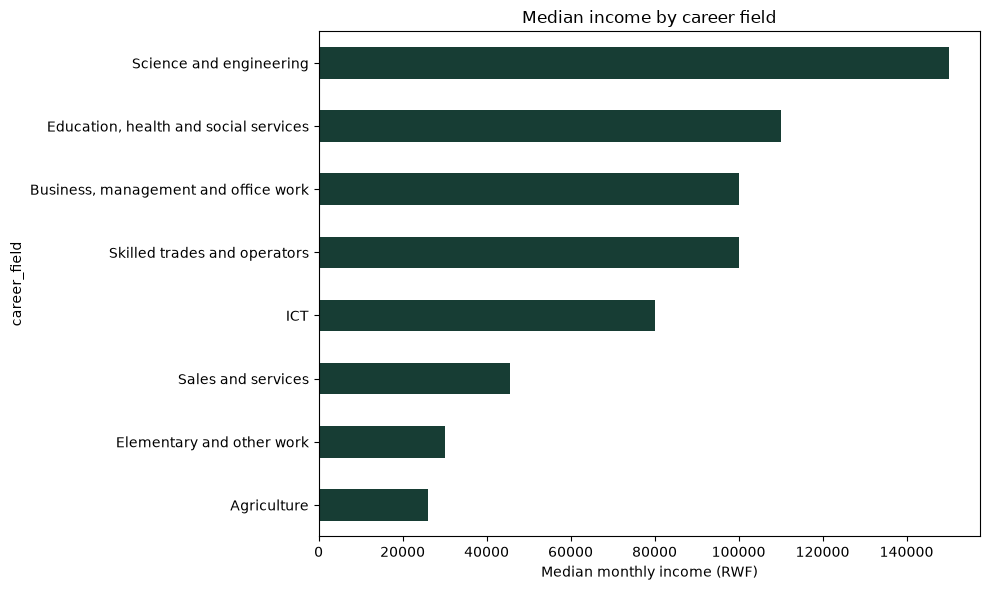

In [18]:
career_income = (
    data.groupby("career_field", observed=True)[TARGET]
    .median()
    .sort_values()
)
plt.figure(figsize=(10, 6))
career_income.plot(kind="barh", color="#173d34")
plt.xlabel("Median monthly income (RWF)")
plt.title("Median income by career field")
plt.tight_layout()
plt.show()

## Standardization and train/test split

`StandardScaler` standardizes age and weekly hours. `OneHotEncoder` converts the text categories to numeric columns.

In [19]:
X_train, X_test, y_train, y_test = split_data(data)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", [c for c in MODEL_FEATURES if c not in NUMERIC_FEATURES])

Training rows: 5225
Test rows: 1307
Numeric features: ['age', 'weekly_hours']
Categorical features: ['education_level', 'career_field', 'main_sector', 'employer_type', 'contract_type', 'residence', 'province']


## Four regression algorithms

- Ordinary Linear Regression is the basic linear benchmark.
- Stochastic Gradient Descent is the second linear implementation and is optimized with five-fold cross-validation.
- Decision Tree learns decision rules.
- Random Forest averages many trees.

the best model is selected only by the lowest test RMSE.

In [20]:
trained_models = {}
metric_rows = []

for name, estimator in model_definitions().items():
    model = tune_sgd(X_train, y_train) if name == "Stochastic Gradient Descent" else make_pipeline(estimator)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    trained_models[name] = model
    metric_rows.append({"model": name, **calculate_metrics(y_test, predictions)})

metrics = pd.DataFrame(metric_rows).set_index("model").sort_values("rmse_rwf")
metrics.round({"rmse_rwf": 2, "mae_rwf": 2, "r2": 3})

,rmse_rwf,mae_rwf,r2
model,,,
Random Forest,30876.25,16914.37,0.556
Stochastic Gradient Descent,30957.55,17964.36,0.553
Ordinary Linear Regression,31021.81,17935.96,0.551
Decision Tree,31793.68,17667.80,0.529


In [21]:
median_prediction = np.repeat(y_train.median(), len(y_test))
baseline = calculate_metrics(y_test, median_prediction)
print("Median baseline:", {name: round(value, 3) for name, value in baseline.items()})

sgd_estimator = trained_models["Stochastic Gradient Descent"].named_steps["regressor"].regressor_
print("Chosen SGD settings:", {
    "alpha": sgd_estimator.alpha,
    "eta0": sgd_estimator.eta0,
    "learning_rate": sgd_estimator.learning_rate,
})

Median baseline: {'rmse_rwf': 49456.362, 'mae_rwf': 26094.954, 'r2': -0.14}
Chosen SGD settings: {'alpha': 0.001, 'eta0': 0.01, 'learning_rate': 'constant'}


## SGD training and test loss

The loss curve shows RMSE after each pass through the data. Both lines should fall and then settle.

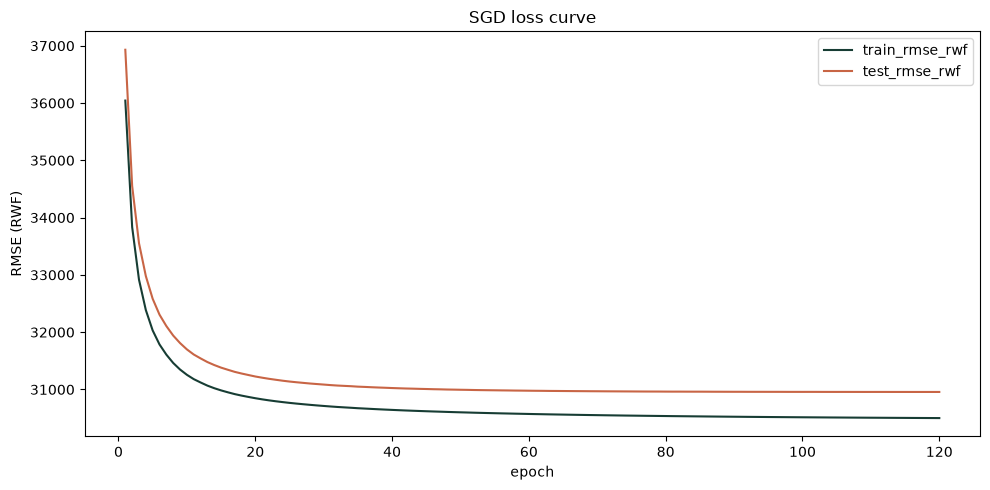

In [22]:
loss_curve = build_sgd_loss_curve(X_train, X_test, y_train, y_test)
loss_curve.plot(
    x="epoch",
    y=["train_rmse_rwf", "test_rmse_rwf"],
    figsize=(10, 5),
    color=["#173d34", "#c86545"],
)
plt.ylabel("RMSE (RWF)")
plt.title("SGD loss curve")
plt.tight_layout()
plt.show()

## Before and after fitted line

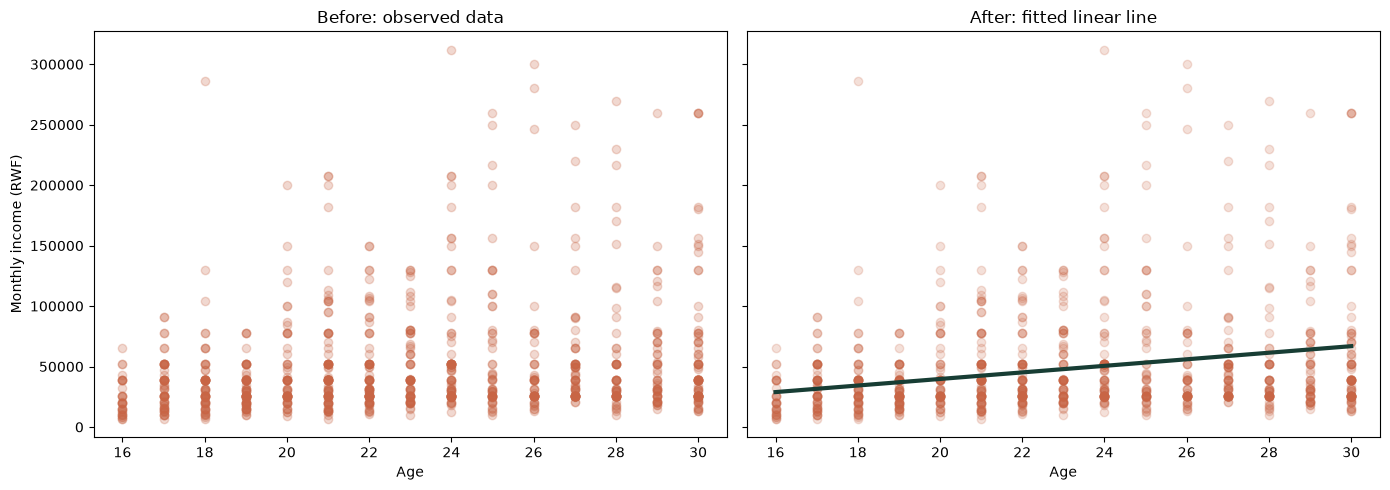

In [23]:
sample = data.sample(min(1000, len(data)), random_state=RANDOM_STATE)
age_line = LinearRegression().fit(data[["age"]], data[TARGET])
ages = pd.DataFrame({"age": np.arange(16, 31)})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].scatter(sample["age"], sample[TARGET], alpha=0.25, color="#c86545")
axes[0].set_title("Before: observed data")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Monthly income (RWF)")

axes[1].scatter(sample["age"], sample[TARGET], alpha=0.20, color="#c86545")
axes[1].plot(ages["age"], age_line.predict(ages), color="#173d34", linewidth=3)
axes[1].set_title("After: fitted linear line")
axes[1].set_xlabel("Age")
plt.tight_layout()
plt.show()

## Save the best model and predict one row

In [24]:
best_name = metrics.index[0]
best_model = trained_models[best_name]
joblib.dump(best_model, MODEL_PATH)

one_row = X_test.iloc[[0]]
actual = float(y_test.iloc[0])
predicted = float(best_model.predict(one_row)[0])

print("Saved model:", best_name)
print("One test row:")
display(one_row)
print(f"Actual income: {actual:,.0f} RWF")
print(f"Predicted income: {predicted:,.0f} RWF")

Saved model: Random Forest
One test row:


,age,education_level,career_field,main_sector,employer_type,contract_type,weekly_hours,residence,province
4111,17,Primary education,Elementary and other work,Services,Household,Oral agreement,42.0,Urban,Eastern Province


Actual income: 15,000 RWF
Predicted income: 16,454 RWF


## Info

- **RMSE** is the typical prediction error with extra punishment for large mistakes. Lower is better.
- **MAE** is the average absolute prediction error. Lower is better.
- **R²** is the share of income variation explained by the model. Higher is better.

When labelled new data arrives, the `/retrain` endpoint validates it, combines it with the existing prepared data, compares the four models again, saves the new winner, and reloads it.